# Classification. Linear models and KNN

In [48]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [49]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import plot_confusion_matrix, accuracy_score
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Part 1: Titanic survival prediction

### Dataset

Read the description here: https://www.kaggle.com/c/titanic/data. Download the dataset and place it in the *data/titanic/* folder in your working directory.
You will use train.csv for model training and validation. The test set is used for model testing: once the model is trained, you can predict whether a passenger survived or not for each passenger in the test set, and submit the predictions: https://www.kaggle.com/c/titanic/overview/evaluation.  


In [50]:
PATH = "./data/"

In [51]:
data = pd.read_csv(os.path.join(PATH, 'titanic', 'train.csv')).set_index('PassengerId')

In [52]:
data_test = pd.read_csv(os.path.join(PATH, 'titanic', 'test.csv')).set_index('PassengerId')

In [53]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### EDA

**(0.5 points)** How many females and males are there in the dataset? What about the survived passengers? Is there any relationship between the gender and the survival?

In [54]:
# males/females
all_gender_counts = data['Sex'].value_counts()
survived_gender_counts = data[data['Survived'] == 1]['Sex'].value_counts()

survival_stats = pd.DataFrame(data={'total': all_gender_counts, 'survived': survived_gender_counts})

In [55]:
survival_stats['survival_percent'] = survival_stats['survived'] / survival_stats['total']

In [56]:
survival_stats

,total,survived,survival_percent
female,314,233,0.742038
male,577,109,0.188908


По имеющимся данным четко прослеживается зависимость между полом пассажира и его выживанием. Выжило 74% женщин

---

**(0.5 points)** Plot age distribution of the passengers. What is the average and the median age of survived and deceased passengers? Do age distributions differ for survived and deceased passengers? Why?

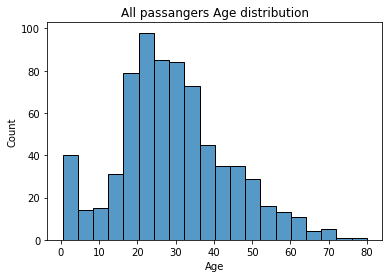

In [57]:
sns.histplot(data=data['Age'], bins=20)
plt.title('All passangers Age distribution')
plt.show()

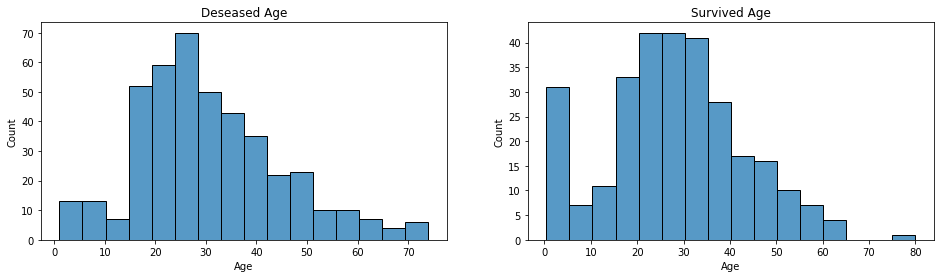

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(data[data['Survived'] == 0]['Age'], ax=ax1)
ax1.set_title('Deseased Age')

sns.histplot(data[data['Survived'] == 1]['Age'], ax=ax2)
ax2.set_title('Survived Age')

plt.show()

In [59]:
data.groupby('Survived').agg({'Age': [np.mean, np.median]})

Age       
               mean median
Survived                  
0         30.626179   28.0
1         28.343690   28.0

По распределению возраста видно, что молодых пассажиров выжило больше.

Средний возраст выживших также ниже, чем средний возраст погибших

---

**(1 point)** EX_trainplore "passenger class" and "embarked" features. What class was "the safest"? Is there any relationship between the embarkation port and the survival? Provide the corresponding visualizations.

In [60]:
pclass_survival = data.groupby(['Pclass', 'Survived']).agg(survived=('Pclass', 'count')).unstack()

In [61]:
pclass_survival['total'] = pclass_survival['survived'].sum(axis=1)
pclass_survival['surv_percent'] = pclass_survival['survived'][1] / pclass_survival['total']

pclass_survival

survived      total surv_percent
Survived        0    1                   
Pclass                                   
1              80  136   216     0.629630
2              97   87   184     0.472826
3             372  119   491     0.242363

In [62]:
embarked_survival = data.groupby(['Embarked', 'Survived']).agg(survived=('Pclass', 'count')).unstack()

In [63]:
embarked_survival['total'] = embarked_survival['survived'].sum(axis=1)
embarked_survival['surv_percent'] = embarked_survival['survived'][1] / embarked_survival['total']

embarked_survival

survived      total surv_percent
Survived        0    1                   
Embarked                                 
C              75   93   168     0.553571
Q              47   30    77     0.389610
S             427  217   644     0.336957

In [64]:
data.groupby(['Survived', 'Embarked', 'Pclass']).size().unstack(-3)

Survived           0   1
Embarked Pclass         
C        1        26  59
         2         8   9
         3        41  25
Q        1         1   1
         2         1   2
         3        45  27
S        1        53  74
         2        88  76
         3       286  67

Класс билета повлиял на вероятность выживания. Состоятельные пассажиры имели больше шанса выжить.

Больше всего выжило пассажиров из порта Cherbourg, но это скорее всего вызвано тем, что доля пассажиров первого класса для данного порта самая большая. Тот факт, что пассажиров из порта Southampton умерло больше также подтверждается тем, что в данном порте бОльшая часть билетов - третьего класса.

---

### Modelling

**(0.5 points)** Find the percentage of missing values for each feature. 

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 123.5+ KB


In [66]:
# missed values percentage
data.isnull().mean() * 100

Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

Think about the ways to handle these missing values for modelling and write your answer below. Which methods would you suggest? What are their advantages and disadvantages?

Для заполнения возраста (Age), возможно стоит использовать предсказание другой модели, потому что он, скорее всего, имеет корреляцию и с классом билета (как и с расходами), и с семейным положением, но я буду использовать медианные значения.

Кабину (Cabin) и Билет (Ticket) можно удалить, так пропущено слишком много значений и вряд ли эти признаки как-то влияют на выживаемость.

Порт (Embarked) заполню занчиями моды.

**(1.5 points)** Prepare the features and train two models (KNN and Logistic Regression) to predict the survival. Compare the results. Use accuracy as a metric. Don't forget about cross-validation!

In [67]:
y = data['Survived']

# убираем метку, которую будем предсказывать и кабину, так как пропущено много занчений
# также, для получения baseline убираем имя и билет
X_train = data.drop(columns=['Survived'])
X_test = data_test.copy()

In [68]:
# Кодируем категориальные фичи
from sklearn.preprocessing import LabelEncoder

**(0.5 + X_train points)** Try more feature engineering and hyperparameter tuning to improve the results. You may use either KNN or Logistic Regression (or both).

#### Drop some features

In [69]:
for dataset in [X_train, X_test]:
    dataset.drop(columns=['Cabin', 'Ticket'], inplace=True)

#### FillNa

In [70]:
for dataset in [X_train, X_test]:
    dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
    dataset['Fare'].fillna(dataset['Fare'].median(), inplace=True)
    dataset['Embarked'].fillna(dataset['Embarked'].mode(), inplace=True)

#### Name

In [71]:
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.')
data['Title'].value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Sir           1
Capt          1
Lady          1
Jonkheer      1
Ms            1
Mme           1
Don           1
Countess      1
Name: Title, dtype: int64

In [72]:
TOP_TITLES = data['Title'].value_counts()[:4].index

In [73]:
def transform_titles(title):
    if title == 'Mlle' or title == 'Ms':
        return 'Miss'
    elif title == 'Mme':
        return 'Mrs'
    elif title not in TOP_TITLES:
        return 'Other'
    else:
        return title

In [74]:
for dataset in [X_train, X_test]:
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.')
    dataset.drop(columns=['Name'], inplace=True)
    dataset['Title'] = dataset['Title'].apply(lambda x: transform_titles(x))

#### Fare

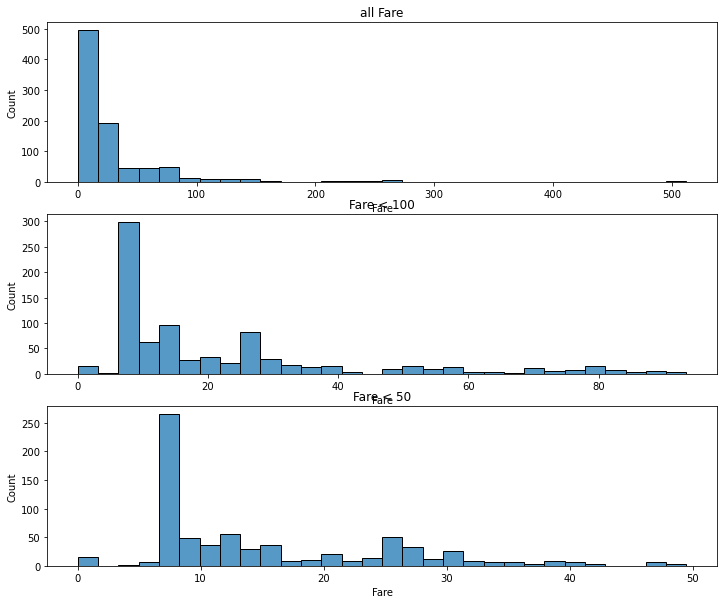

In [75]:
fig, (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

sns.histplot(X_train['Fare'], bins=30, ax=ax)
ax.set_title('all Fare')

sns.histplot(X_train['Fare'][X_train['Fare'] < 100], bins=30, ax=ax2)
ax2.set_title('Fare < 100')

sns.histplot(X_train['Fare'][X_train['Fare'] < 50], bins=30, ax=ax3)
ax3.set_title('Fare < 50')

plt.show()

#### SibSP, Parch

In [76]:
# Объединим признак родственников (SibSp, Parch) в один
for dataset in [X_train, X_test]:
    dataset['SoloTrip'] = dataset.apply(lambda x: x['SibSp'] == 0 and x['Parch'] == 0, axis=1).astype(int)
    dataset.drop(columns=['SibSp', 'Parch'], inplace=True)

#### Encoders

In [77]:
lable_enc = LabelEncoder()

In [78]:
def make_fare_groups(val):
    if val <= 8: return 0
    elif 8 < val <= 15: return 1
    elif 15 < val <= 35: return 2
    else: return 3

In [79]:
# transform features
for dataset in [X_train, X_test]:
    dataset['Sex'] = dataset['Sex'].apply(lambda x: 1 if x == 'male' else 0)
    dataset['Age'] = pd.cut(dataset['Age'], 10, precision=0, labels=range(10)).astype(int)
    dataset['Fare'] = dataset['Fare'].apply(lambda x: make_fare_groups(x))


In [80]:
# one hot encoding
def one_hot_encode(x, one_hot_cols):
    for col in one_hot_cols:
        x = x.join(pd.get_dummies(x[col], prefix=col)).drop(columns=[col])
    return x

one_hot_cols = ['Pclass', 'Age', 'Fare', 'Embarked', 'Title']

X_train = one_hot_encode(X_train, one_hot_cols)
X_test = one_hot_encode(X_test, one_hot_cols)

In [81]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#### Models

In [82]:
lr_model = LogisticRegression()
knn_model = KNeighborsClassifier(n_neighbors=3)

In [83]:
pipe_lr = make_pipeline(
    MinMaxScaler(),
    lr_model
)

pipe_knn = make_pipeline(
    MinMaxScaler(),
    knn_model
)

In [84]:
cross_validate(pipe_lr, X_train, y, cv=5, scoring='accuracy')['test_score'].mean()

0.7968740192078337

In [85]:
cross_validate(pipe_knn, X_train, y, cv=5, scoring='accuracy')['test_score'].mean()

0.780051471972883

### Best Model (not)

In [86]:
lr_model.fit(X_train, y)

LogisticRegression()

In [87]:
lr_model.coef_

array([[-1.5350529 ,  0.50208658,  1.01772568,  0.13667123, -1.15320592,
         0.84682651,  0.14031144,  0.15852959,  0.25735397,  0.22245412,
        -0.28702628, -0.1036349 , -0.54562595, -1.13979379,  0.45179628,
         0.16144651, -0.18790925, -0.08583583,  0.11348956,  0.27349817,
        -0.02672085, -0.36150831,  1.19194799,  0.10416887, -1.1401641 ,
         0.73772004, -0.89248181]])

In [88]:
test_predict = lr_model.predict(X_test)

Load the test set and make the predictions. Submit them to kaggle and see the results :)
Select the best model, load the test set and make the predictions. Submit them to kaggle.

**Note**. X points will depend on your kaggle leaderboard score.
$$ f(score) = 0.5, \ \ 0.76 \leq score < 0.78,$$
$$ f(score) = 1.0, \ \ 0.78 \leq score < 0.81,$$ 
$$ f(score) = 2.5, \ \ 0.81 \leq score $$ 
Your code should generate the output submitted to kaggle. Fix random seeds to make the results reproducible.

In [89]:
submit = pd.read_csv(os.path.join(PATH, 'titanic', 'gender_submission.csv'))

In [90]:
submit['Survived'] = test_predict

In [92]:
submit.to_csv('submit_final.csv', index=False)

Kaggle Score: 0.76794
Nickname: Dionis

Кто может - объясните, что я делаю не так. Не смог выжать больше

---

## Part 2: Porto Seguro’s Safe Driver Prediction

Let's build a model that predicts the probability that a driver will initiate an auto insurance claim in the neX_traint year.
Read the detailed description and download the dataset https://www.kaggle.com/c/porto-seguro-safe-driver-prediction/data. Put the data into *./data/porto/*.

In [ ]:
insurance_data = pd.read_csv(os.path.join(PATH, 'porto', 'train.csv')).set_indeX_train('id')

In [ ]:
insurance_data.head()

Let's skip EDA for now. We'll use SGDClassifier and build a simple baseline: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html.
Note that loss='log' gives logistic regression.

In [ ]:
y = insurance_data['target']
X_train = insurance_data.drop(columns=['target'])

In [ ]:
numeric_features = [column for column in X_train if not (column.endswith("cat") or column.endswith("bin"))]
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_features = [column for column in X_train if (column.endswith("cat") or column.endswith("bin"))]
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', SGDClassifier(loss='log', alpha=0.001, n_jobs=-1, random_state=14))])

In [ ]:
X_train_train, X_train_valid, y_train, y_valid = train_test_split(X_train, y, test_size=0.3, random_state=42)

In [ ]:
clf = pipeline.fit(X_train_train, y_train)

We'll calculate the model accuracy:

In [ ]:
accuracy_score(y_true=y_valid, y_pred=clf.predict(X_train_valid))

Wow! Our model gets ~0.963 accuracy! But is it really good?...

Let's plot the confusion matriX_train and analyze the errors.

In [ ]:
disp = plot_confusion_matriX_train(clf, X_train_valid, y_valid,
                             cmap=plt.cm.Blues,
                             normalize=None)

Well, it turns out that our model is completely useless. Let's calculate some basic statistics:

In [ ]:
insurance_data.describe()

As you see, there are less than 4% of positive eX_trainamples, so we have to deal with a highly imbalanced dataset.

In [ ]:
sns.countplot(X_train='target', data=insurance_data)
plt.show()

Accuracy is not informative here and the Normalized Gini Coefficient will be used instead: https://www.kaggle.com/c/porto-seguro-safe-driver-prediction/overview/evaluation.

In [ ]:
# Code for calculating Normalized gini coefficient
# https://www.kaggle.com/c/ClaimPredictionChallenge/discussion/703
def gini(actual, pred, cmpcol = 0, sortcol = 1):  
    assert(len(actual) == len(pred))  
    epsilon = 1e-7
    values = np.asarray(np.c_[actual, pred, np.arange(len(actual))], dtype=np.float)  
    values = values[np.leX_trainsort((values[:, 2], -1 * values[:, 1]))]  
    total = values[:, 0].sum() 
    gini_sum = (values[:, 0].cumsum().sum() + epsilon) / (total + epsilon)  
  
    gini_sum -= (len(actual) + 1) / 2  
    return gini_sum / len(actual)  
  
def gini_normalized(a, p):  
    '''Function to calculate the normalized gini coefficient'''
    return gini(a, p) / gini(a, a)

**(1.5 points)** Prove that the **Normalized Gini Coefficient** is equivalent to **2 X_train AUC - 1** :

< your proof >

**(0.5 points)** By the way, what other metrics could you suggest for this problem?

< your thoughts >

Let's calculate the Normalized Gini Coefficient:

In [ ]:
y_pred = clf.predict_proba(X_train_valid)[:, 1]

In [ ]:
gini_normalized(y_valid, y_pred)

**(0.5 points + Y bonus points)** Try different approaches: oversampling / undersampling, careful feature analysis and feature engineering, etc., to get a reasonable pipeline and improve the model quality. Use cross-validation for model evaluation.

Select the best model, load the test set and make the predictions. Submit them to kaggle.
Y bonus points will be calculated as $\frac{round(200 * \maX_train(score - 0.253, 0))}{2}$, where *score* is your kaggle leaderboard score.

Note: do not use any classification models which have not been covered in the lessons yet.

In [ ]:
## your code